**Pre-processing full scale data**

In [ ]:
import pandas as pd
from itertools import combinations
from collections import Counter

# Load dataset
file_path = '/content/drive/MyDrive/ML Project/diabetic_data.csv'
df = pd.read_csv(file_path)

# Display relevant columns
print(df[['encounter_id', 'patient_nbr', 'diag_1', 'diag_2', 'diag_3']].head())

# Filter and drop rows with missing diagnosis info
df = df[['patient_nbr', 'diag_1', 'diag_2', 'diag_3']].dropna()

# Convert all diagnosis codes to strings for consistency
df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].astype(str)

# 🔍 Function to map ICD-9 codes to disease categories
def map_icd9_to_category(code):
    try:
        code = float(code)
    except:
        return 'Other'

    if (390 <= code <= 459) or (code == 785):
        return 'Circulatory'
    elif (460 <= code <= 519) or (code == 786):
        return 'Respiratory'
    elif (520 <= code <= 579) or (code == 787):
        return 'Digestive'
    elif code == 250:
        return 'Diabetes'
    elif (800 <= code <= 999):
        return 'Injury'
    elif (710 <= code <= 739):
        return 'Musculoskeletal'
    elif (580 <= code <= 629) or (code == 788):
        return 'Genitourinary'
    elif (140 <= code <= 239):
        return 'Neoplasms'
    elif (680 <= code <= 709):
        return 'Skin'
    elif (240 <= code <= 279):
        return 'Endocrine'
    elif (290 <= code <= 319):
        return 'Mental Disorders'
    else:
        return 'Other'

# Apply mapping to diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_icd9_to_category)

# Group diagnoses per patient
diagnoses_per_patient = df.groupby('patient_nbr')[['diag_1', 'diag_2', 'diag_3']].agg(lambda x: list(x)).reset_index()

# Create co-occurrence pairs
diagnosis_sets = diagnoses_per_patient.apply(lambda row: list(set(row['diag_1'] + row['diag_2'] + row['diag_3'])), axis=1)

co_occurrence_counter = Counter()

for diag_list in diagnosis_sets:
    if len(diag_list) >= 2:
        pairs = combinations(sorted(set(diag_list)), 2)
        co_occurrence_counter.update(pairs)

# Build edge list DataFrame
co_occurrence_df = pd.DataFrame(
    [(a, b, count) for (a, b), count in co_occurrence_counter.items()],
    columns=["Disease A", "Disease B", "Co-occurrence Count"]
)

# Optional: Filter out low-frequency co-occurrences
co_occurrence_df = co_occurrence_df[co_occurrence_df["Co-occurrence Count"] >= 10]

# Display and save
print(co_occurrence_df.head())
co_occurrence_df.to_csv('/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv', index=False)


   encounter_id  patient_nbr  diag_1  diag_2 diag_3
0       2278392      8222157  250.83       ?      ?
1        149190     55629189     276  250.01    255
2         64410     86047875     648     250    V27
3        500364     82442376       8  250.43    403
4         16680     42519267     197     157    250
     Disease A  Disease B  Co-occurrence Count
0  Circulatory   Diabetes                10365
1  Circulatory  Digestive                 5787
2  Circulatory     Injury                 4846
3  Circulatory      Other                13671
4     Diabetes  Digestive                 2950


**Creation of graph**

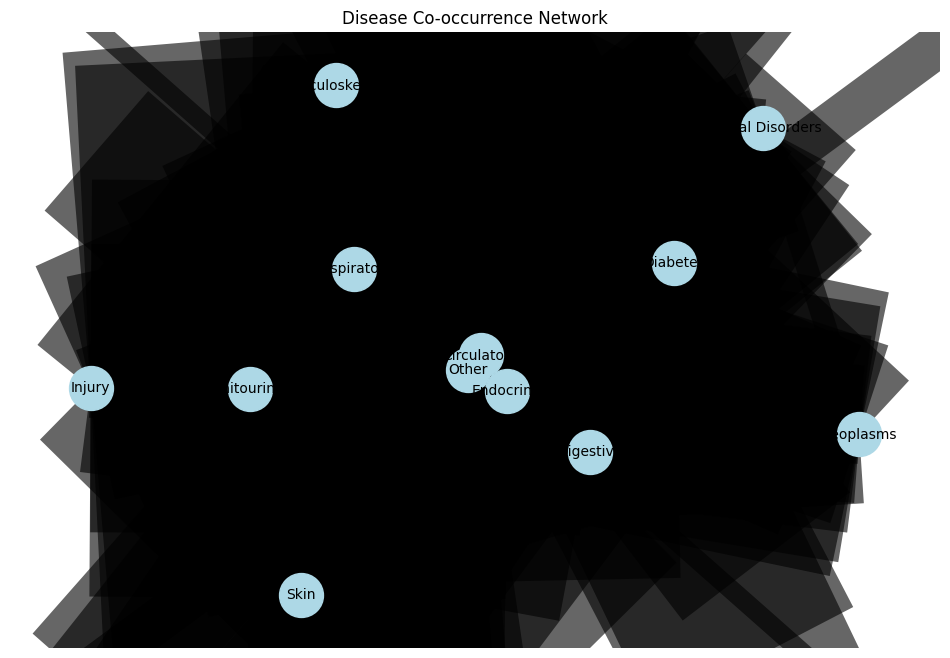

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the edge list
edge_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
edges_df = pd.read_csv(edge_path)

# Filter for clarity (optional if already done)
edges_df = edges_df[edges_df["Co-occurrence Count"] >= 10]

# Create the graph
G = nx.Graph()

# Add edges and weights
for _, row in edges_df.iterrows():
    G.add_edge(row['Disease A'], row['Disease B'], weight=row['Co-occurrence Count'])

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # layout for consistent positioning

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='lightblue')

# Draw edges (thicker lines for higher weights)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w / 10 for w in weights], alpha=0.6)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

plt.title('Disease Co-occurrence Network')
plt.axis('off')
plt.show()


**Improved graph view**

<ipython-input-4-40ac4b4933c2>:21: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


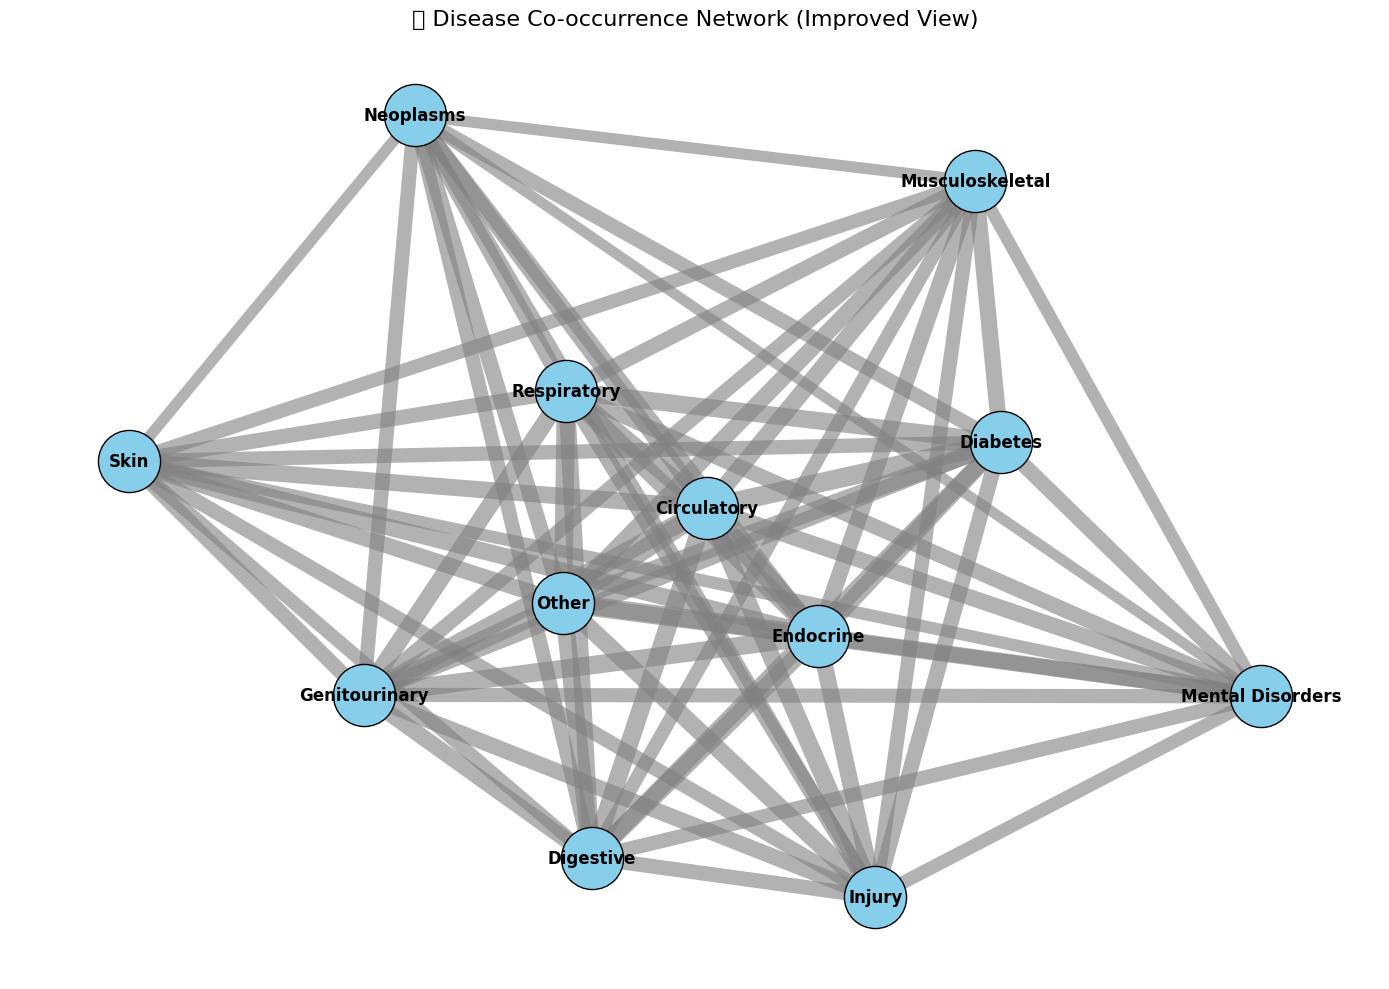

In [ ]:
import numpy as np

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)  # increase node spacing

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', edgecolors='black')

# Rescale edge widths (log scale for balance)
weights = [G[u][v]['weight'] for u, v in G.edges()]
scaled_weights = [np.log(w + 1) * 1.5 for w in weights]

# Draw edges
nx.draw_networkx_edges(G, pos, width=scaled_weights, alpha=0.6, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif', font_weight='bold')

plt.title('🧬 Disease Co-occurrence Network (Improved View)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


**Centrality and community detection**

<ipython-input-5-42c4f95f809e>:35: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


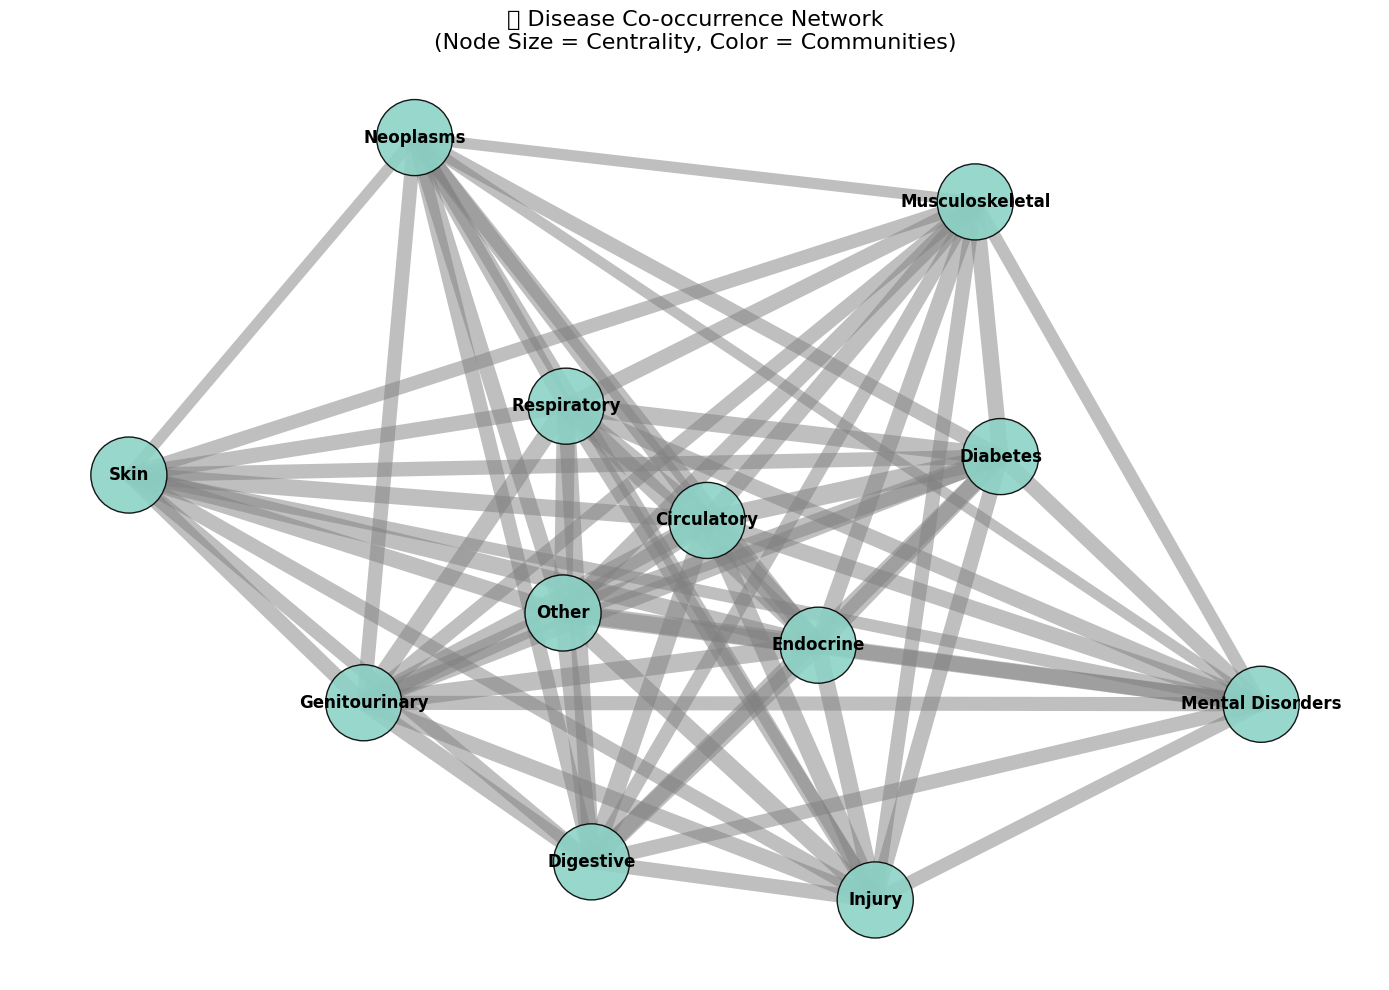

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import community as community_louvain  # install via pip install python-louvain

# Centrality: Degree Centrality
centrality = nx.degree_centrality(G)
node_sizes = [3000 * centrality[node] for node in G.nodes()]

# Community Detection using Louvain
partition = community_louvain.best_partition(G)
communities = list(set(partition.values()))
color_map = [partition[node] for node in G.nodes()]

# Define color palette
colors = plt.cm.Set3(np.linspace(0, 1, len(communities)))

# Visualization
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=[colors[i] for i in color_map],
    alpha=0.9,
    edgecolors='black'
)
weights = [np.log(G[u][v]['weight'] + 1) * 1.5 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif', font_weight='bold')

plt.title("🧠 Disease Co-occurrence Network\n(Node Size = Centrality, Color = Communities)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


**Top nodes and Communities**

In [ ]:
# Top 5 nodes by centrality
top_central = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("📌 Top Central Nodes (Degree Centrality):")
for disease, cent in top_central:
    print(f"{disease}: {cent:.3f}")

# Diameter & Average Shortest Path
if nx.is_connected(G):
    print(f"📏 Diameter: {nx.diameter(G)}")
    print(f"📐 Average Shortest Path: {nx.average_shortest_path_length(G):.2f}")
else:
    print("⚠️ Graph is not fully connected, computing for the largest component.")
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc)
    print(f"📏 Diameter: {nx.diameter(G_lcc)}")
    print(f"📐 Average Shortest Path: {nx.average_shortest_path_length(G_lcc):.2f}")

# Number of communities
print(f"🎯 Total Communities Detected: {len(communities)}")


📌 Top Central Nodes (Degree Centrality):
Circulatory: 1.000
Diabetes: 1.000
Digestive: 1.000
Injury: 1.000
Other: 1.000
📏 Diameter: 1
📐 Average Shortest Path: 1.00
🎯 Total Communities Detected: 1


**Saving Gephi format**

In [ ]:
# Save for Gephi (GEXF format)
nx.write_gexf(G, '/content/drive/MyDrive/ML Project/disease_network.gexf')


**Community size**

<ipython-input-8-c7c847abb4e7>:20: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


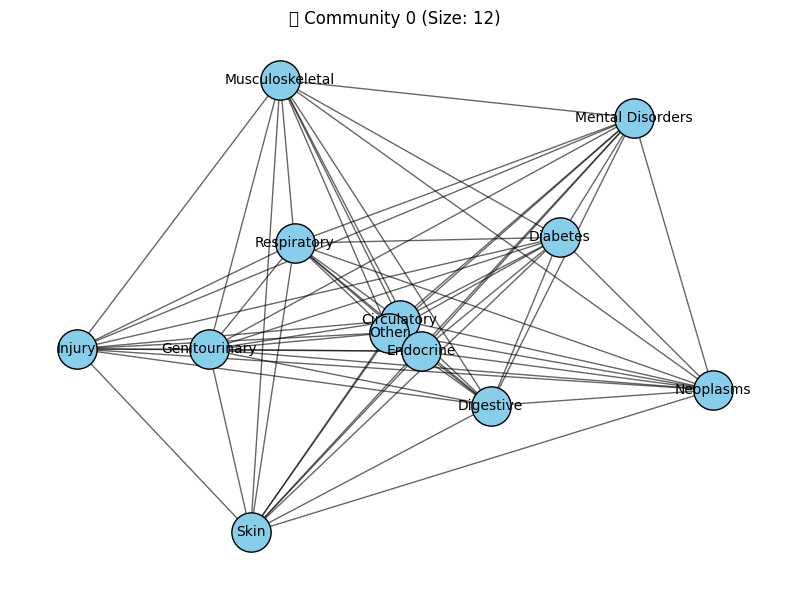

In [ ]:
from collections import defaultdict

# Group nodes by community
community_nodes = defaultdict(list)
for node, comm in partition.items():
    community_nodes[comm].append(node)

# Plot each community separately
for comm, nodes in community_nodes.items():
    subgraph = G.subgraph(nodes)
    pos = nx.spring_layout(subgraph, seed=42)

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(subgraph, pos, node_size=800, node_color='skyblue', edgecolors='black')
    nx.draw_networkx_edges(subgraph, pos, width=1, alpha=0.6)
    nx.draw_networkx_labels(subgraph, pos, font_size=10)

    plt.title(f"🧬 Community {comm} (Size: {len(nodes)})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


**Shortest path between two diseases**

🔗 Shortest Path: Diabetes → Circulatory


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


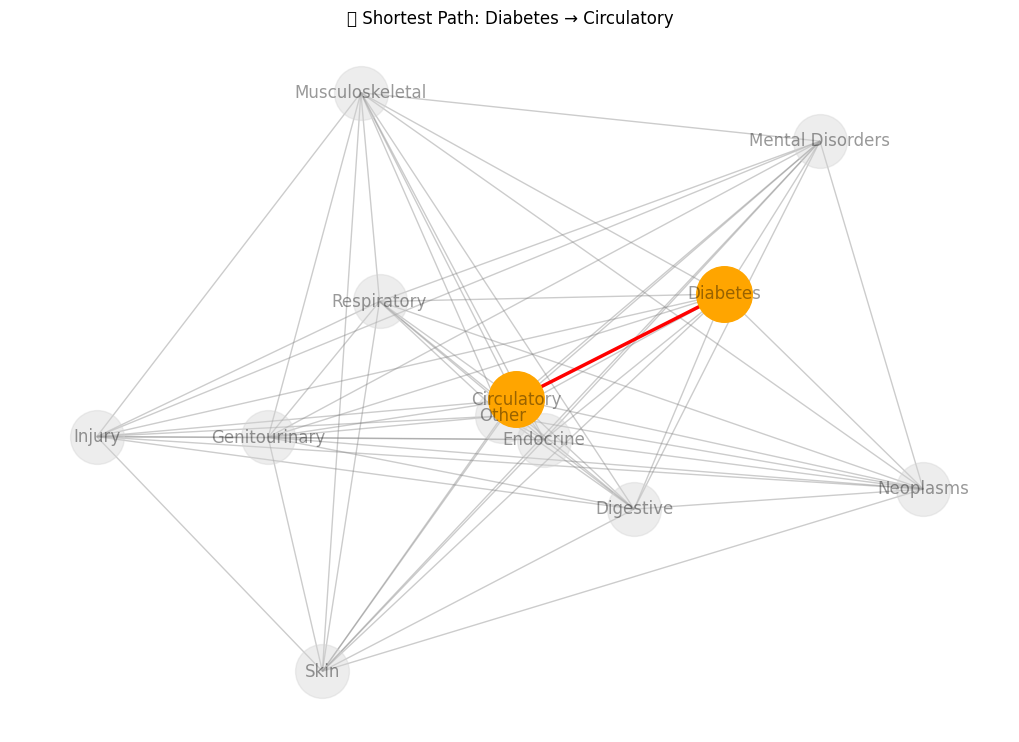

In [ ]:
# Shortest path between two diseases
source = "Diabetes"
target = "Circulatory"

if nx.has_path(G, source, target):
    path = nx.shortest_path(G, source=source, target=target)
    print("🔗 Shortest Path:", " → ".join(path))

    edge_list = list(zip(path[:-1], path[1:]))
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 7))
    nx.draw(G, pos, with_labels=True, node_size=1500, node_color='lightgray', edge_color='gray', alpha=0.4)
    nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='orange', node_size=1600)
    nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color='red', width=2.5)
    plt.title(f"🔍 Shortest Path: {source} → {target}")
    plt.axis('off')
    plt.show()
else:
    print(f"❌ No path exists between {source} and {target}")


**Log generation**

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Build graph from co-occurrence dataframe
G = nx.Graph()

# Add edges and weights
for _, row in co_occurrence_df.iterrows():
    G.add_edge(row['Disease A'], row['Disease B'], weight=row['Co-occurrence Count'])

# 2. Save graph to .graphml file
graph_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence.graphml'
nx.write_graphml(G, graph_path)

# 3. Generate log file with graph statistics
log_lines = []
log_lines.append("📊 Disease Co-occurrence Graph Statistics\n")
log_lines.append(f"Number of nodes: {G.number_of_nodes()}")
log_lines.append(f"Number of edges: {G.number_of_edges()}")
log_lines.append(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
log_lines.append(f"Density: {nx.density(G):.4f}")
log_lines.append(f"Is connected: {nx.is_connected(G)}")
log_lines.append(f"Number of connected components: {nx.number_connected_components(G)}")

# Largest component stats
largest_cc = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc)
log_lines.append(f"\n🔍 Largest Component Stats:")
log_lines.append(f"Size: {G_largest.number_of_nodes()} nodes, {G_largest.number_of_edges()} edges")
log_lines.append(f"Average clustering coefficient: {nx.average_clustering(G_largest):.4f}")

# Write log to file
log_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_log.txt'
with open(log_path, 'w') as log_file:
    for line in log_lines:
        log_file.write(line + '\n')

# Optional: print the log summary
for line in log_lines:
    print(line)


📊 Disease Co-occurrence Graph Statistics

Number of nodes: 12
Number of edges: 66
Average degree: 11.00
Density: 1.0000
Is connected: True
Number of connected components: 1

🔍 Largest Component Stats:
Size: 12 nodes, 66 edges
Average clustering coefficient: 1.0000


1. **Preprocessing**
2. **Saving .graphml**
3. **Graph log generation**


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import logging
from itertools import combinations
from collections import Counter
from datetime import datetime

# === Setup Logging ===
log_path_txt = '/content/drive/MyDrive/ML Project/disease_co_occurrence_log.txt'
log_path_runtime = '/content/drive/MyDrive/ML Project/graph_creation.log'

logging.basicConfig(
    filename=log_path_runtime,
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("🚀 Starting disease co-occurrence graph creation.")

# === Load and Preprocess Dataset ===
file_path = '/content/drive/MyDrive/ML Project/diabetic_data.csv'
df = pd.read_csv(file_path)
logging.info(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

# Keep relevant columns and drop missing
df = df[['patient_nbr', 'diag_1', 'diag_2', 'diag_3']].dropna()
logging.info(f"Filtered dataset: {df.shape[0]} rows remaining after dropping missing diagnoses.")

# Convert diagnosis codes to string
df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].astype(str)

# === Map ICD-9 Codes to Categories ===
def map_icd9_to_category(code):
    try:
        code = float(code)
    except:
        return 'Other'
    if (390 <= code <= 459) or (code == 785):
        return 'Circulatory'
    elif (460 <= code <= 519) or (code == 786):
        return 'Respiratory'
    elif (520 <= code <= 579) or (code == 787):
        return 'Digestive'
    elif code == 250:
        return 'Diabetes'
    elif (800 <= code <= 999):
        return 'Injury'
    elif (710 <= code <= 739):
        return 'Musculoskeletal'
    elif (580 <= code <= 629) or (code == 788):
        return 'Genitourinary'
    elif (140 <= code <= 239):
        return 'Neoplasms'
    elif (680 <= code <= 709):
        return 'Skin'
    elif (240 <= code <= 279):
        return 'Endocrine'
    elif (290 <= code <= 319):
        return 'Mental Disorders'
    else:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_icd9_to_category)

unique_categories = set(df['diag_1']).union(set(df['diag_2'])).union(set(df['diag_3']))
logging.info(f"Mapped diagnosis codes to {len(unique_categories)} unique disease categories.")

# === Extract Co-occurrence Pairs ===
diagnoses_per_patient = df.groupby('patient_nbr')[['diag_1', 'diag_2', 'diag_3']].agg(lambda x: list(x)).reset_index()
diagnosis_sets = diagnoses_per_patient.apply(lambda row: list(set(row['diag_1'] + row['diag_2'] + row['diag_3'])), axis=1)

co_occurrence_counter = Counter()
for diag_list in diagnosis_sets:
    if len(diag_list) >= 2:
        pairs = combinations(sorted(set(diag_list)), 2)
        co_occurrence_counter.update(pairs)

logging.info(f"Extracted {len(co_occurrence_counter)} unique disease co-occurrence pairs.")

# Convert to DataFrame and apply threshold
co_occurrence_df = pd.DataFrame(
    [(a, b, count) for (a, b), count in co_occurrence_counter.items()],
    columns=["Disease A", "Disease B", "Co-occurrence Count"]
)

co_occurrence_df = co_occurrence_df[co_occurrence_df["Co-occurrence Count"] >= 10]
logging.info(f"Filtered co-occurrence pairs to {co_occurrence_df.shape[0]} (threshold ≥10).")

# === Build Graph ===
G = nx.Graph()
for _, row in co_occurrence_df.iterrows():
    G.add_edge(row['Disease A'], row['Disease B'], weight=row['Co-occurrence Count'])

logging.info(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# === Save Graph to File ===
graph_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence.graphml'
nx.write_graphml(G, graph_path)
logging.info(f"Graph saved to {graph_path}")

# === Save Graph Statistics Log ===
log_lines = []
log_lines.append("📊 Disease Co-occurrence Graph Statistics")
log_lines.append(f"Date: {datetime.now()}")
log_lines.append(f"Number of nodes: {G.number_of_nodes()}")
log_lines.append(f"Number of edges: {G.number_of_edges()}")
log_lines.append(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
log_lines.append(f"Density: {nx.density(G):.4f}")
log_lines.append(f"Is connected: {nx.is_connected(G)}")
log_lines.append(f"Number of connected components: {nx.number_connected_components(G)}")

largest_cc = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc)
log_lines.append("\n🔍 Largest Component Stats:")
log_lines.append(f"Size: {G_largest.number_of_nodes()} nodes, {G_largest.number_of_edges()} edges")
log_lines.append(f"Average clustering coefficient: {nx.average_clustering(G_largest):.4f}")

with open(log_path_txt, 'w') as f:
    for line in log_lines:
        f.write(line + '\n')

logging.info(f"Graph statistics saved to {log_path_txt}")

# === Optional: Print Log Summary ===
print("\n".join(log_lines))


📊 Disease Co-occurrence Graph Statistics
Date: 2025-05-21 07:24:29.102506
Number of nodes: 12
Number of edges: 66
Average degree: 11.00
Density: 1.0000
Is connected: True
Number of connected components: 1

🔍 Largest Component Stats:
Size: 12 nodes, 66 edges
Average clustering coefficient: 1.0000


**Assignment 4**

**Degree Centrality**

Sample data:
     Disease A  Disease B  Co-occurrence Count
0  Circulatory   Diabetes                10365
1  Circulatory  Digestive                 5787
2  Circulatory     Injury                 4846
3  Circulatory      Other                13671
4     Diabetes  Digestive                 2950

Top 10 nodes by Degree Centrality:
               Node  Degree Centrality
0       Circulatory                1.0
1          Diabetes                1.0
2         Digestive                1.0
3            Injury                1.0
4             Other                1.0
5  Mental Disorders                1.0
6   Musculoskeletal                1.0
7       Respiratory                1.0
8         Endocrine                1.0
9     Genitourinary                1.0


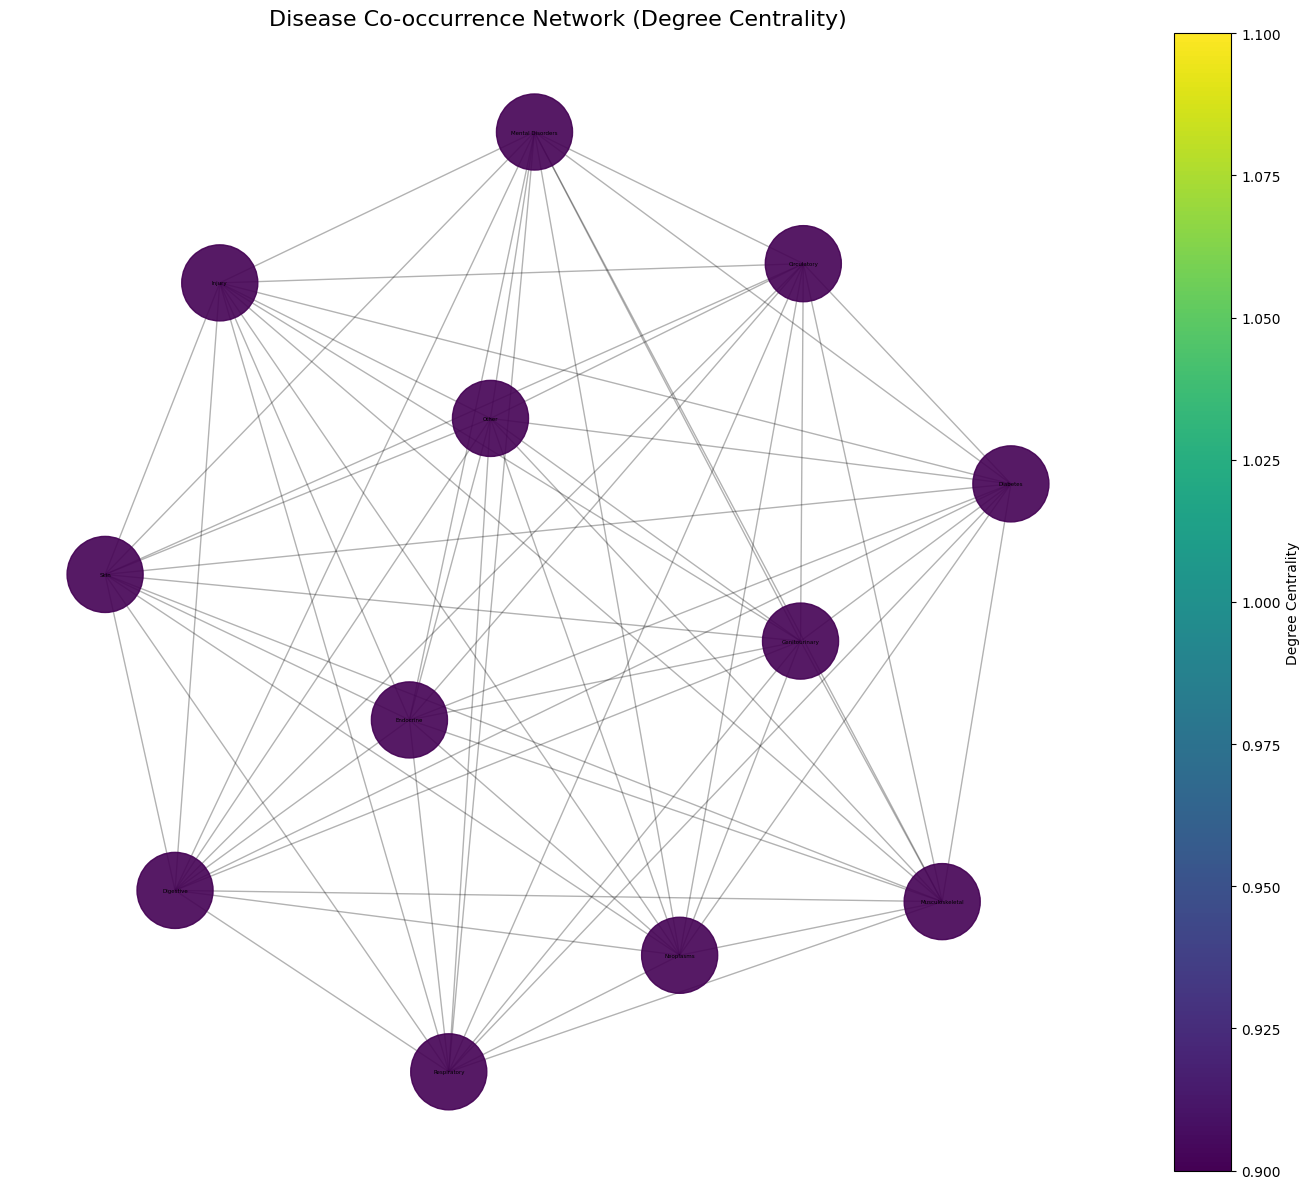

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load the CSV file
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Step 2: Display first few rows to verify the structure
print("Sample data:")
print(df.head())

# Step 3: Create an undirected graph from the edge list
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Step 4: Calculate degree centrality
degree_centrality = nx.degree_centrality(G)

# Step 5: Convert to DataFrame for easier viewing
centrality_df = pd.DataFrame(degree_centrality.items(), columns=['Node', 'Degree Centrality'])

# Step 6: Sort and display top 10 nodes
centrality_df = centrality_df.sort_values(by='Degree Centrality', ascending=False)
print("\nTop 10 nodes by Degree Centrality:")
print(centrality_df.head(10))

# Step 7: Visualize the graph
# Get layout
pos = nx.spring_layout(G, seed=42)

# Get node sizes and colors based on degree centrality
node_sizes = [3000 * degree_centrality[node] for node in G.nodes()]
node_colors = [degree_centrality[node] for node in G.nodes()]

# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the graph on the specified axes
nodes = nx.draw_networkx_nodes(G, pos,
                               node_size=node_sizes,
                               node_color=node_colors,
                               cmap=plt.cm.viridis,
                               alpha=0.9,
                               ax=ax) # Specify axes
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax) # Specify axes
nx.draw_networkx_labels(G, pos, font_size=4, ax=ax) # Specify axes

# Add color bar, explicitly linking it to the axes
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([]) # This is needed for colorbar to work with ScalarMappable

# Pass the axes object 'ax' to the colorbar function
plt.colorbar(sm, ax=ax, label='Degree Centrality')

# Final plot settings using the axes object
ax.set_title("Disease Co-occurrence Network (Degree Centrality)", fontsize=16) # Use ax.set_title
ax.axis('off') # Use ax.axis
plt.tight_layout()
plt.show()

**Betweeness Centrality**

Sample data:
     Disease A  Disease B  Co-occurrence Count
0  Circulatory   Diabetes                10365
1  Circulatory  Digestive                 5787
2  Circulatory     Injury                 4846
3  Circulatory      Other                13671
4     Diabetes  Digestive                 2950

Top 10 nodes by Betweenness Centrality:
               Node  Betweenness Centrality
0       Circulatory                     0.0
1          Diabetes                     0.0
2         Digestive                     0.0
3            Injury                     0.0
4             Other                     0.0
5  Mental Disorders                     0.0
6   Musculoskeletal                     0.0
7       Respiratory                     0.0
8         Endocrine                     0.0
9     Genitourinary                     0.0


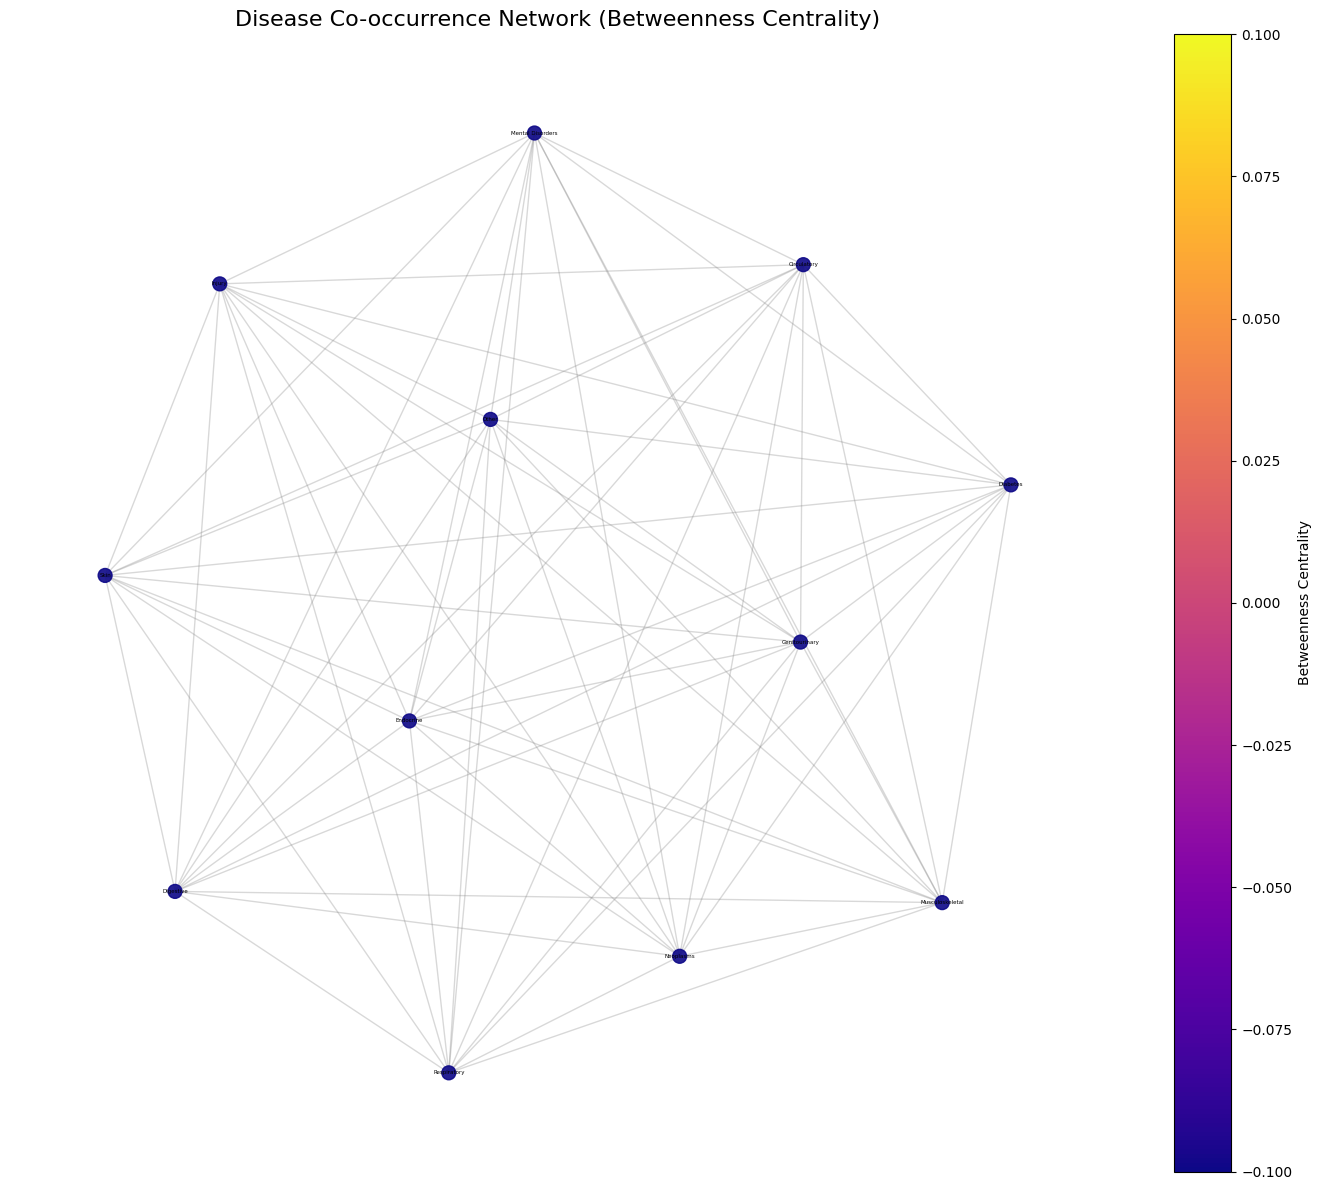

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Load the CSV file
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Step 2: Display the first few rows
print("Sample data:")
print(df.head())

# Step 3: Create an undirected graph from the edge list
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Step 4: Compute betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)

# Step 5: Convert centrality to a DataFrame and show top nodes
centrality_df = pd.DataFrame(betweenness_centrality.items(), columns=['Node', 'Betweenness Centrality'])
centrality_df = centrality_df.sort_values(by='Betweenness Centrality', ascending=False)

print("\nTop 10 nodes by Betweenness Centrality:")
print(centrality_df.head(10))

# Step 6: Visualize the graph
# Get layout
pos = nx.spring_layout(G, seed=42)

# Get node sizes and colors based on betweenness centrality
node_sizes = [5000 * betweenness_centrality[node] + 100 for node in G.nodes()]
node_colors = [betweenness_centrality[node] for node in G.nodes()]

# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the graph, explicitly drawing onto 'ax'
nodes = nx.draw_networkx_nodes(G, pos,
                               node_size=node_sizes,
                               node_color=node_colors,
                               cmap=plt.cm.plasma,
                               alpha=0.9,
                               ax=ax) # Specify axes
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, ax=ax) # Specify axes
nx.draw_networkx_labels(G, pos, font_size=4, ax=ax) # Specify axes

# Add colorbar, explicitly linking it to the axes
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Betweenness Centrality') # Specify axes for the colorbar

# Final touches using the axes object
ax.set_title("Disease Co-occurrence Network (Betweenness Centrality)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

**Closeness Centrality**

Sample data:
     Disease A  Disease B  Co-occurrence Count
0  Circulatory   Diabetes                10365
1  Circulatory  Digestive                 5787
2  Circulatory     Injury                 4846
3  Circulatory      Other                13671
4     Diabetes  Digestive                 2950

Top 10 nodes by Closeness Centrality:
               Node  Closeness Centrality
0       Circulatory                   1.0
1          Diabetes                   1.0
2         Digestive                   1.0
3            Injury                   1.0
4             Other                   1.0
5  Mental Disorders                   1.0
6   Musculoskeletal                   1.0
7       Respiratory                   1.0
8         Endocrine                   1.0
9     Genitourinary                   1.0


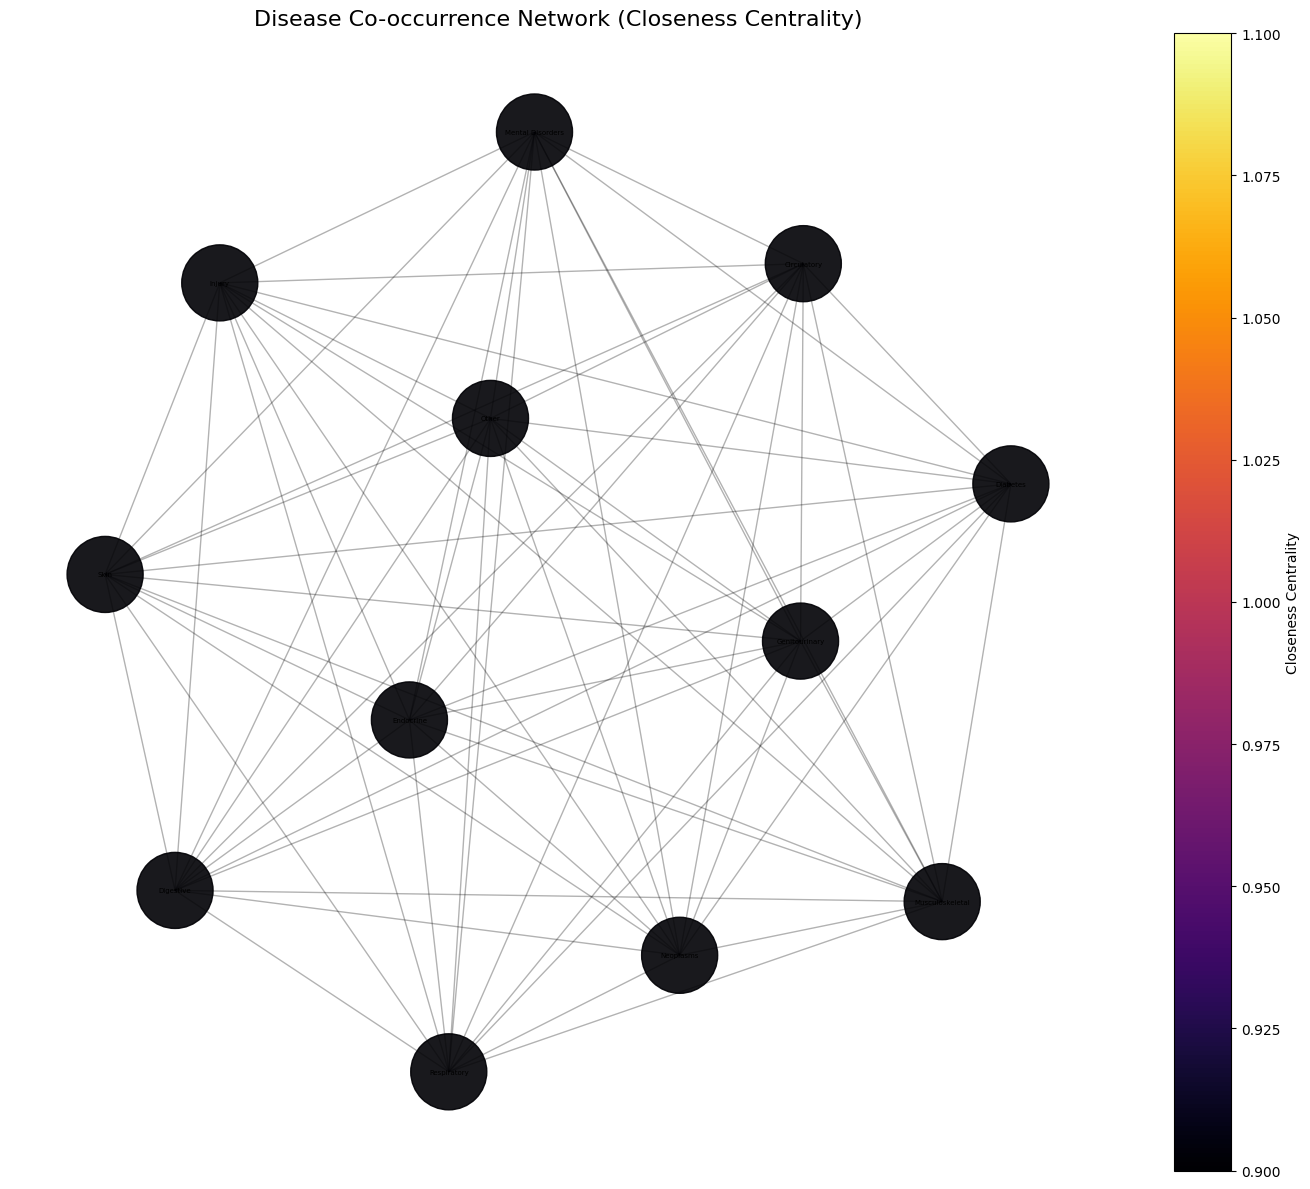

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Load the CSV file
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Step 2: Display first few rows
print("Sample data:")
print(df.head())

# Step 3: Create an undirected graph
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Step 4: Compute closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Step 5: Convert to DataFrame and display top 10 nodes
centrality_df = pd.DataFrame(closeness_centrality.items(), columns=['Node', 'Closeness Centrality'])
centrality_df = centrality_df.sort_values(by='Closeness Centrality', ascending=False)

print("\nTop 10 nodes by Closeness Centrality:")
print(centrality_df.head(10))

# Step 6: Visualization
# Get layout
pos = nx.spring_layout(G, seed=42)

# Scale node sizes and colors by closeness centrality
node_sizes = [3000 * closeness_centrality[node] for node in G.nodes()]
node_colors = [closeness_centrality[node] for node in G.nodes()]

# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(14, 12))

# Draw the graph, explicitly drawing onto 'ax'
nodes = nx.draw_networkx_nodes(G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       cmap=plt.cm.inferno,
                       alpha=0.9,
                       ax=ax) #Specify axes
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax) #Specify axes
nx.draw_networkx_labels(G, pos, font_size=5, ax=ax) #Specify axes

# Add colorbar, explicitly linking it to the axes
sm = plt.cm.ScalarMappable(cmap=plt.cm.inferno,
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Closeness Centrality') #Specify axes for the colorbar

# Final plot settings using the axes object
ax.set_title("Disease Co-occurrence Network (Closeness Centrality)", fontsize=16) #Use ax.set_title
ax.axis('off') #Use ax.axis
plt.tight_layout()
plt.show()

**Eigenvector Centrality**

Sample data:
     Disease A  Disease B  Co-occurrence Count
0  Circulatory   Diabetes                10365
1  Circulatory  Digestive                 5787
2  Circulatory     Injury                 4846
3  Circulatory      Other                13671
4     Diabetes  Digestive                 2950

Top 10 nodes by Eigenvector Centrality:
               Node  Eigenvector Centrality
0       Circulatory                0.288675
1          Diabetes                0.288675
2         Digestive                0.288675
3            Injury                0.288675
4             Other                0.288675
5  Mental Disorders                0.288675
6   Musculoskeletal                0.288675
7       Respiratory                0.288675
8         Endocrine                0.288675
9     Genitourinary                0.288675


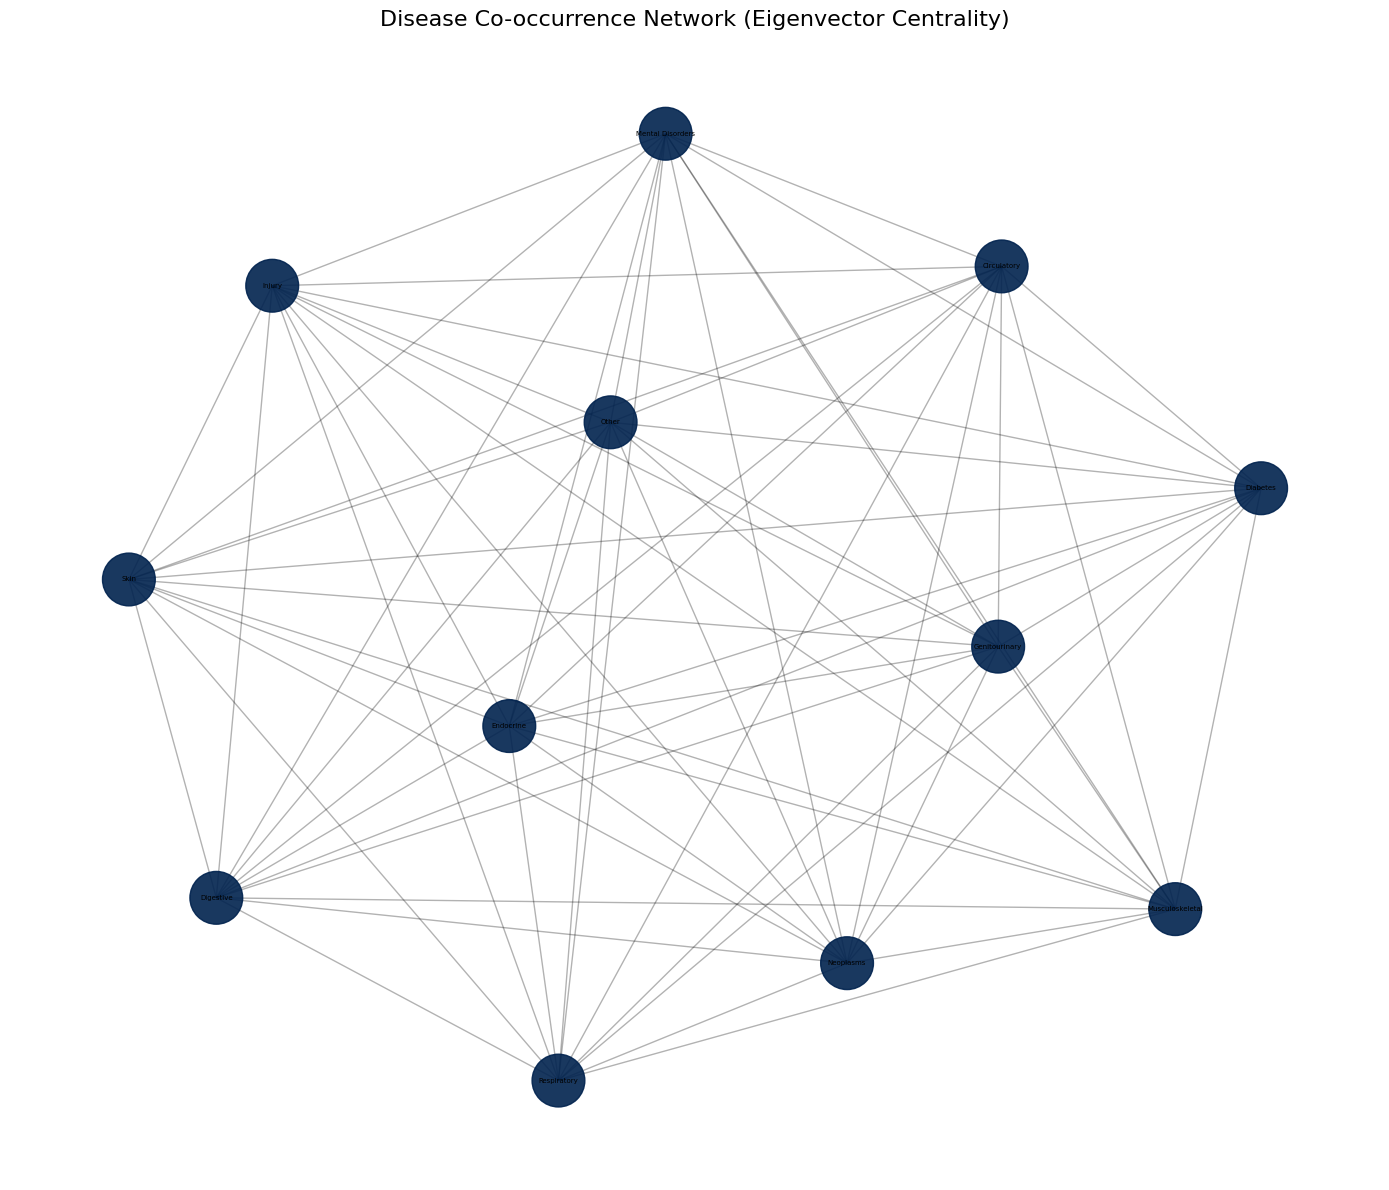

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Load the dataset
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Step 2: Preview the data
print("Sample data:")
print(df.head())

# Step 3: Create an undirected graph
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Step 4: Compute eigenvector centrality
# Use max_iter to ensure convergence; catch exceptions for disconnected graphs
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
except nx.NetworkXException as e:
    print("Error computing eigenvector centrality:", e)
    # If centrality cannot be computed, set it to an empty dictionary
    eigenvector_centrality = {}


# Check if eigenvector_centrality is empty or contains valid data before proceeding
if not eigenvector_centrality:
    print("Eigenvector centrality could not be computed. Cannot proceed with visualization.")
else:
    # Step 5: Create DataFrame of centrality values and display top 10
    centrality_df = pd.DataFrame(eigenvector_centrality.items(), columns=['Node', 'Eigenvector Centrality'])
    centrality_df = centrality_df.sort_values(by='Eigenvector Centrality', ascending=False)

    print("\nTop 10 nodes by Eigenvector Centrality:")
    print(centrality_df.head(10))

    # Step 6: Visualize the graph
    pos = nx.spring_layout(G, seed=42)

    # Ensure centrality values are not all zero before scaling
    if max(eigenvector_centrality.values()) == 0:
         # If all values are zero, assign a default size or handle appropriately
         node_sizes = [5000 * 0.1 for node in G.nodes()] # Assign a small default size
         node_colors = [0 for node in G.nodes()] # All nodes same color
         print("Warning: All eigenvector centrality values are zero.")
    else:
        node_sizes = [5000 * eigenvector_centrality[node] for node in G.nodes()]
        node_colors = [eigenvector_centrality[node] for node in G.nodes()]


    # Create figure and axes explicitly
    fig, ax = plt.subplots(figsize=(14, 12)) #Create figure and axes

    # Draw the graph onto the axes 'ax'
    nodes = nx.draw_networkx_nodes(G, pos,
                           node_size=node_sizes,
                           node_color=node_colors,
                           cmap=plt.cm.cividis,
                           alpha=0.9,
                           ax=ax) #Specify axes
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax) #Specify axes
    nx.draw_networkx_labels(G, pos, font_size=5, ax=ax) #Specify axes

    # Add colorbar, explicitly linking it to the axes 'ax'
    # Check if node_colors is not empty and contains a range before creating ScalarMappable
    if len(node_colors) > 0 and min(node_colors) != max(node_colors):
        sm = plt.cm.ScalarMappable(cmap=plt.cm.cividis,
                                   norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
        sm.set_array([]) # Needed for colorbar
        plt.colorbar(sm, ax=ax, label='Eigenvector centrality') #Specify axes for colorbar
    elif len(node_colors) > 0:
        print("Warning: All nodes have the same eigenvector centrality. Colorbar not added.")
    else:
         print("Warning: No nodes in graph. Colorbar not added.")


    # Finalize plot settings using the axes object
    ax.set_title("Disease Co-occurrence Network (Eigenvector Centrality)", fontsize=16) #Use ax.set_title
    ax.axis('off') #Use ax.axis
    plt.tight_layout()
    plt.show()

**Page Rank**

Sample data:
     Disease A  Disease B  Co-occurrence Count
0  Circulatory   Diabetes                10365
1  Circulatory  Digestive                 5787
2  Circulatory     Injury                 4846
3  Circulatory      Other                13671
4     Diabetes  Digestive                 2950

Top 10 nodes by PageRank:
               Node  PageRank
0       Circulatory  0.083333
1          Diabetes  0.083333
2         Digestive  0.083333
3            Injury  0.083333
4             Other  0.083333
5  Mental Disorders  0.083333
6   Musculoskeletal  0.083333
7       Respiratory  0.083333
8         Endocrine  0.083333
9     Genitourinary  0.083333


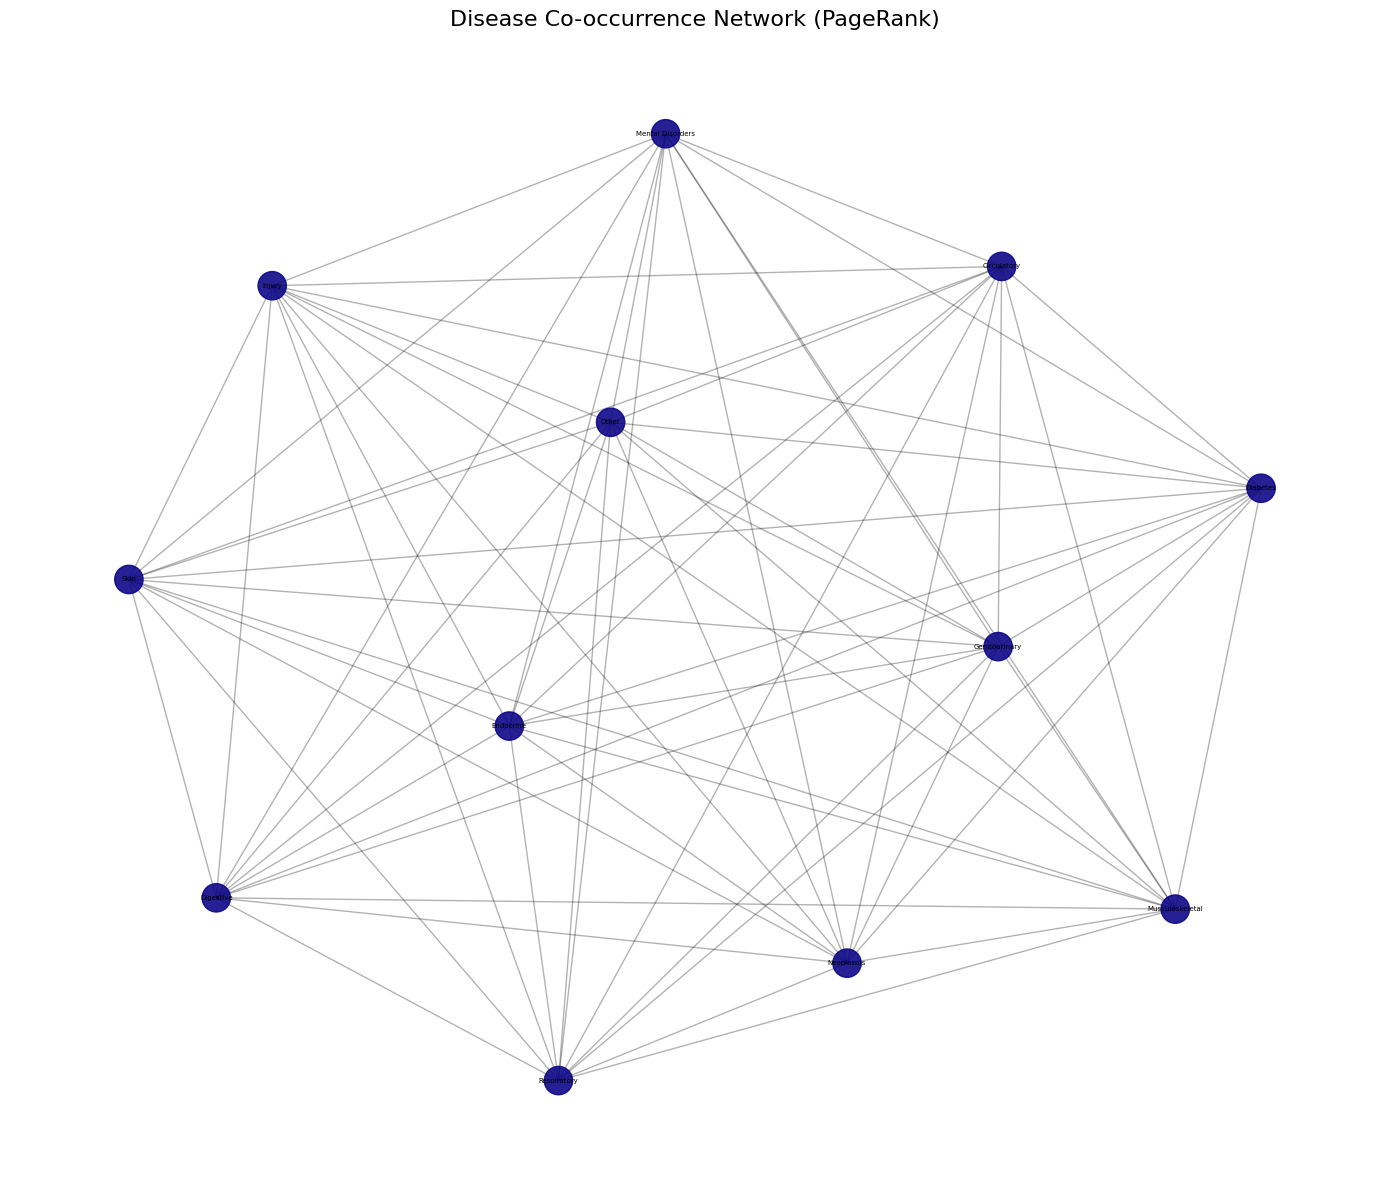

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Load the dataset
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Step 2: Preview data
print("Sample data:")
print(df.head())

# Step 3: Create an undirected graph
# Adjust column names if needed
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Step 4: Compute PageRank
pagerank = nx.pagerank(G)

# Step 5: Convert to DataFrame and display top 10 nodes by PageRank
pagerank_df = pd.DataFrame(pagerank.items(), columns=['Node', 'PageRank'])
pagerank_df = pagerank_df.sort_values(by='PageRank', ascending=False)

print("\nTop 10 nodes by PageRank:")
print(pagerank_df.head(10))

# Step 6: Visualization
pos = nx.spring_layout(G, seed=42)

# Scale node sizes and colors based on PageRank
# Ensure centrality values are not all zero before scaling
if max(pagerank.values()) == 0:
     # If all values are zero, assign a default size or handle appropriately
     node_sizes = [5000 * 0.1 for node in G.nodes()] # Assign a small default size
     node_colors = [0 for node in G.nodes()] # All nodes same color
     print("Warning: All pagerank values are zero.")
else:
    node_sizes = [5000 * pagerank[node] for node in G.nodes()]
    node_colors = [pagerank[node] for node in G.nodes()]


# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(14, 12)) #Create figure and axes

# Draw the graph onto the axes 'ax'
nodes = nx.draw_networkx_nodes(G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       cmap=plt.cm.plasma,
                       alpha=0.9,
                       ax=ax) #Specify axes
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax) #Specify axes
nx.draw_networkx_labels(G, pos, font_size=5, ax=ax) #Specify axes

# Add colorbar, explicitly linking it to the axes 'ax'
# Check if node_colors is not empty and contains a range before creating ScalarMappable
if len(node_colors) > 0 and min(node_colors) != max(node_colors):
    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
                               norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
    sm.set_array([]) # Needed for colorbar
    plt.colorbar(sm, ax=ax, label='PageRank') #Specify axes for colorbar
elif len(node_colors) > 0:
    print("Warning: All nodes have the same pagerank. Colorbar not added.")
else:
     print("Warning: No nodes in graph. Colorbar not added.")

# Final plot settings using the axes object
ax.set_title("Disease Co-occurrence Network (PageRank)", fontsize=16) #Use ax.set_title
ax.axis('off') #Use ax.axis
plt.tight_layout()
plt.show()

**Integrating centrality measures for comprehensive analysis**

**Degree centrality & Eigen vector centrality**



**Application: Identifying hub diseases**

In [ ]:
import pandas as pd
import networkx as nx

# Load data
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Build graph
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Compute centralities
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Combine into DataFrame
centrality_df = pd.DataFrame({
    'Node': list(degree_centrality.keys()),
    'Degree Centrality': list(degree_centrality.values()),
    'Eigenvector Centrality': [eigenvector_centrality[node] for node in degree_centrality.keys()]
})

# Define thresholds - for example, median values
degree_thresh = centrality_df['Degree Centrality'].median()
eigenvector_thresh = centrality_df['Eigenvector Centrality'].median()

# Identify hubs: nodes with both centralities above their thresholds
hubs = centrality_df[
    (centrality_df['Degree Centrality'] >= degree_thresh) &
    (centrality_df['Eigenvector Centrality'] >= eigenvector_thresh)
]

# Optionally, add combined score to rank hubs
hubs['Combined Score'] = hubs['Degree Centrality'] + hubs['Eigenvector Centrality']

# Sort by combined score descending
hubs = hubs.sort_values(by='Combined Score', ascending=False)

# Display hub diseases
print("Identified Hub Diseases (High Degree & Eigenvector Centrality):")
print(hubs[['Node', 'Degree Centrality', 'Eigenvector Centrality', 'Combined Score']])


Identified Hub Diseases (High Degree & Eigenvector Centrality):
                Node  Degree Centrality  Eigenvector Centrality  \
0        Circulatory                1.0                0.288675   
1           Diabetes                1.0                0.288675   
2          Digestive                1.0                0.288675   
3             Injury                1.0                0.288675   
4              Other                1.0                0.288675   
5   Mental Disorders                1.0                0.288675   
6    Musculoskeletal                1.0                0.288675   
7        Respiratory                1.0                0.288675   
8          Endocrine                1.0                0.288675   
9      Genitourinary                1.0                0.288675   
10         Neoplasms                1.0                0.288675   
11              Skin                1.0                0.288675   

    Combined Score  
0         1.288675  
1         1.288675  
2

**Betweeness**

**Application: Detecting Bridge Diseases**

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load dataset
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Build graph
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Compute betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Convert to DataFrame
bc_df = pd.DataFrame(list(betweenness.items()), columns=['Node', 'Betweenness Centrality'])

# Define threshold (e.g., median)
threshold = bc_df['Betweenness Centrality'].median()

# Identify bridge diseases: nodes with betweenness above threshold
bridge_diseases = bc_df[bc_df['Betweenness Centrality'] >= threshold]

print("Bridge Diseases (High Betweenness Centrality):")
print(bridge_diseases.sort_values(by='Betweenness Centrality', ascending=False))



Bridge Diseases (High Betweenness Centrality):
                Node  Betweenness Centrality
0        Circulatory                     0.0
1           Diabetes                     0.0
2          Digestive                     0.0
3             Injury                     0.0
4              Other                     0.0
5   Mental Disorders                     0.0
6    Musculoskeletal                     0.0
7        Respiratory                     0.0
8          Endocrine                     0.0
9      Genitourinary                     0.0
10         Neoplasms                     0.0
11              Skin                     0.0


**Closeness centrality & Page Rank**

**Assessing Disease Influence**

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load data
file_path = '/content/drive/MyDrive/ML Project/disease_co_occurrence_edges.csv'
df = pd.read_csv(file_path)

# Build graph
G = nx.from_pandas_edgelist(df, source='Disease A', target='Disease B', edge_attr='Co-occurrence Count')

# Compute centralities
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

# Create DataFrame combining closeness and pagerank
centrality_df = pd.DataFrame({
    'Node': list(closeness.keys()),
    'Closeness Centrality': list(closeness.values()),
    'PageRank': [pagerank[node] for node in closeness.keys()]
})

# Define thresholds (e.g., median values)
closeness_thresh = centrality_df['Closeness Centrality'].median()
pagerank_thresh = centrality_df['PageRank'].median()

# Identify influential diseases with high closeness and pagerank
influential = centrality_df[
    (centrality_df['Closeness Centrality'] >= closeness_thresh) &
    (centrality_df['PageRank'] >= pagerank_thresh)
]

# Add combined influence score for ranking
influential['Combined Influence'] = influential['Closeness Centrality'] + influential['PageRank']

# Sort influential diseases by combined influence descending
influential = influential.sort_values(by='Combined Influence', ascending=False)

print("Influential Diseases (High Closeness & PageRank):")
print(influential[['Node', 'Closeness Centrality', 'PageRank', 'Combined Influence']])



Influential Diseases (High Closeness & PageRank):
                Node  Closeness Centrality  PageRank  Combined Influence
0        Circulatory                   1.0  0.083333            1.083333
1           Diabetes                   1.0  0.083333            1.083333
2          Digestive                   1.0  0.083333            1.083333
3             Injury                   1.0  0.083333            1.083333
4              Other                   1.0  0.083333            1.083333
5   Mental Disorders                   1.0  0.083333            1.083333
6    Musculoskeletal                   1.0  0.083333            1.083333
7        Respiratory                   1.0  0.083333            1.083333
8          Endocrine                   1.0  0.083333            1.083333
9      Genitourinary                   1.0  0.083333            1.083333
10         Neoplasms                   1.0  0.083333            1.083333
11              Skin                   1.0  0.083333            1.083333
